# 04 — Leakage-audited classification and honest baselines

**Task:** predict next-day direction (up/down) from information available at
end of day *t*.

**Leakage rules** (enforced mechanically in `tests/test_leakage.py`, which
corrupts all post-cutoff data and asserts features before the cutoff don't move):

1. Features at *t* use only headlines dated ≤ *t* and prices dated ≤ *t*
2. Labels come only from day *t+1*, and only for genuine consecutive sessions
3. Validation is walk-forward: each test block is later than everything trained on
4. Feature scaling is fit inside each fold on training rows only (Pipeline)

**Baseline honesty:** the S&P 500 drifts upward, so "always predict up" is right
on most days. 50% is not the bar — the always-up baseline is.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

from src.data import load_headlines
from src.sentiment import score_headlines
from src.features import build_model_frame, modeling_subset, FEATURE_COLS
from src.model import walk_forward, baseline_results, accuracy_vs_baseline_test, naive_backtest

scored = score_headlines(load_headlines())
df = build_model_frame(scored)
sub = modeling_subset(df)
print(f"modeling rows: {len(sub):,}  ({sub.date.min().date()} -> {sub.date.max().date()})")
print(f"share of up days: {sub.next_up.mean():.1%}")
print(f"features: {FEATURE_COLS}")

modeling rows: 3,209  (2008-01-09 -> 2024-03-01)
share of up days: 53.9%
features: ['sent_mean', 'share_pos', 'share_neg', 'sent_std', 'sent_mean_lag1', 'sent_mean_roll3', 'sent_change', 'log_n_headlines', 'ret', 'ret_lag1', 'vol5']


In [2]:
logit = walk_forward(sub, kind="logistic", n_folds=5, min_train=500)
gbm = walk_forward(sub, kind="gbm", n_folds=5, min_train=500)
bases = baseline_results(sub, logit.predictions["date"])

results = [logit, gbm] + bases
summary = pd.DataFrame({
    "model": [r.name for r in results],
    "accuracy": [r.accuracy for r in results],
    "balanced_acc": [r.balanced_accuracy for r in results],
    "auc": [r.auc for r in results],
}).round(4)
summary

,model,accuracy,balanced_acc,auc
0,logistic (walk-forward),0.5345,0.5027,0.4996
1,gbm (walk-forward),0.5186,0.5003,0.4997
2,always up,0.5393,0.5000,0.5000
3,persistence (today's direction),0.4725,0.4689,0.4689
4,coin flip,0.5042,0.5028,0.5028


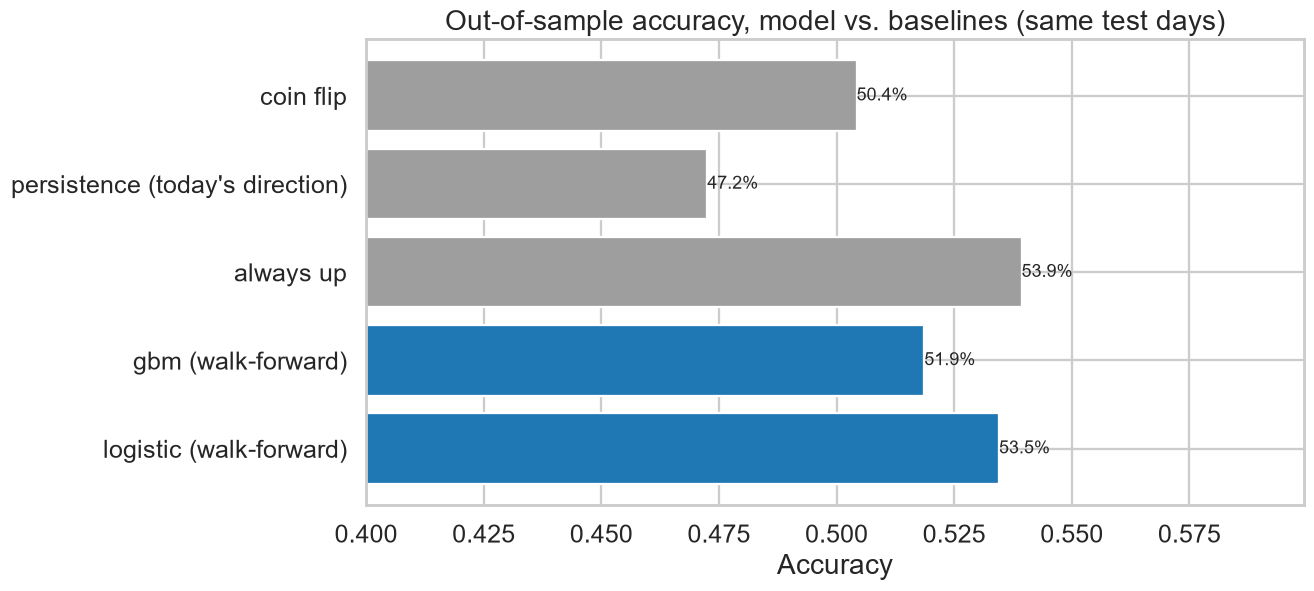

In [3]:
from src.plots import model_vs_baselines
from IPython.display import Image
model_vs_baselines(results)
Image("../reports/figures/06_model_vs_baselines.png")

## Is the model actually better than "always up"?

McNemar's exact test on the days where the model and the baseline disagree —
the correct paired comparison for two classifiers on the same test days.

In [4]:
always_up = bases[0]
for m in (logit, gbm):
    t = accuracy_vs_baseline_test(m, always_up)
    print(f"{m.name} vs always-up: model-only-correct = {t['model_only_correct']}, "
          f"baseline-only-correct = {t['baseline_only_correct']}, p = {t['p_value']:.4f}")

logistic (walk-forward) vs always-up: model-only-correct = 122, baseline-only-correct = 135, p = 0.4542
gbm (walk-forward) vs always-up: model-only-correct = 333, baseline-only-correct = 389, p = 0.0406


## Sentiment-only ablation

How much of the (any) skill comes from sentiment rather than the price/volatility
features?

In [5]:
sent_only = [c for c in FEATURE_COLS if c.startswith("sent") or c.startswith("share") or c == "log_n_headlines"]
price_only = [c for c in FEATURE_COLS if c not in sent_only]
for name, cols in [("sentiment features only", sent_only), ("price features only", price_only)]:
    r = walk_forward(sub, kind="logistic", n_folds=5, min_train=500, feature_cols=cols)
    print(f"{name:>25}: accuracy = {r.accuracy:.4f}, auc = {r.auc:.4f}")

  sentiment features only: accuracy = 0.5308, auc = 0.4944
      price features only: accuracy = 0.5463, auc = 0.5017


## What "using this signal" would have meant — illustration, not advice

Hold the index on days the model says up, cash otherwise. No transaction costs,
no slippage, no taxes — deliberately generous assumptions, because the point is
that even under generous assumptions a near-coin-flip signal does not produce a
usable strategy. **This is a methodology exhibit, not a trading recommendation.**

In [6]:
bt = naive_backtest(logit)
n_trades = int((bt.strategy_ret != 0).sum())
in_market = (logit.predictions.y_pred == 1).mean()
print(f"out-of-sample days: {len(bt):,}   days in market: {in_market:.1%}")
print(f"final growth of $1 — buy & hold: {bt.bh_curve.iloc[-1]:.2f}   signal: {bt.strat_curve.iloc[-1]:.2f}")

out-of-sample days: 2,709   days in market: 90.5%
final growth of $1 — buy & hold: 2.94   signal: 3.60


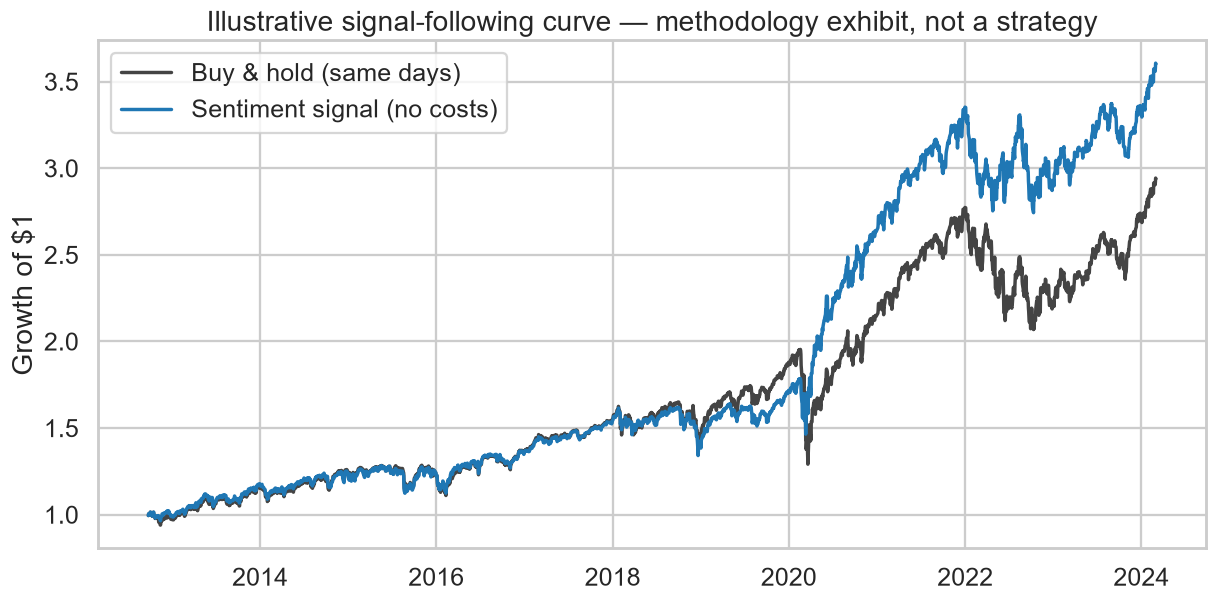

In [7]:
from src.plots import backtest_curves
backtest_curves(bt)
Image("../reports/figures/07_backtest_illustration.png")

## Honest summary

The result table above is reported exactly as computed. The expectations going
in, from a large academic literature: daily index direction is close to a coin
flip; text sentiment adds at most a small, unstable edge concentrated in
high-attention periods; and a close-to-close design with day-granular
timestamps cannot capture the fast part of any news reaction.

Whatever the numbers show above, the leakage controls mean they are at least
*real* numbers: no future information reached any feature, no fold trained on
its own test period, and the baselines sat on the same test days.